In [ ]:
!pip install higher scikit-learn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
from torch.utils.data import Dataset
import numpy as np
import random
from sklearn.metrics import f1_score, accuracy_score
import higher

In [ ]:

# =========================
# 2. TRANSFORMS
# =========================
transform_train = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [ ]:
transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:

# =========================
# 3. DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

!wget -O dataset.zip "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded" && unzip dataset.zip

#plantDoc Dataset
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git



Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1327).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1328).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1329).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (133).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1330).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1331).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1332).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1333).JPG  
  infl

In [ ]:
plantvillage = datasets.ImageFolder(
    "/content/Plant_leave_diseases_dataset_with_augmentation",
    transform=transform_train
)

plantdoc = datasets.ImageFolder(
    "/content/PlantDoc-Dataset/train",
    transform=transform_train
)

print("PlantVillage:", len(plantvillage))
print("PlantDoc:", len(plantdoc))

PlantVillage: 61486
PlantDoc: 2342


In [ ]:
class CombinedDataset(Dataset):
    def __init__(self, d1, d2):
        self.d1 = d1
        self.d2 = d2
        self.targets = d1.targets + d2.targets # Add this line to combine targets

    def __len__(self):
        return len(self.d1) + len(self.d2)

    def __getitem__(self, idx):
        if idx < len(self.d1):
            img,label = self.d1[idx]
            return img,label,0
        else:
            img,label = self.d2[idx-len(self.d1)]
            return img,label,1

combined_dataset = CombinedDataset(plantdoc, plantvillage)

In [ ]:
class MobileNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.mobilenet_v2(weights="DEFAULT")

        self.backbone = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        # MobileNetV2 last channel = 1280
        self.fc = nn.Linear(1280, 128)

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:


# =========================
# 7. LOSSES
# =========================
class SupConLoss(nn.Module):
    def __init__(self,temp=0.07):
        super().__init__()
        self.temp=temp

    def forward(self,f,l):
        f = F.normalize(f,dim=1)
        sim = torch.matmul(f,f.T)/self.temp

        l = l.unsqueeze(1)
        mask = torch.eq(l,l.T).float().to(f.device)

        logits_mask = torch.ones_like(mask) - torch.eye(mask.shape[0]).to(f.device)
        mask = mask * logits_mask

        exp = torch.exp(sim) * logits_mask
        log_prob = sim - torch.log(exp.sum(1,keepdim=True))

        return -(mask * log_prob).sum(1).mean()

def compute_prototypes(features, labels, n_way):
    return torch.stack([
        features[labels==c].mean(0) for c in range(n_way)
    ])

def domain_loss(features, labels, domains, n_way):

    loss = 0
    count = 0

    for c in range(n_way):
        src = features[(labels==c) & (domains==0)]
        tgt = features[(labels==c) & (domains==1)]

        if len(src)>0 and len(tgt)>0:
            loss += F.mse_loss(src.mean(0), tgt.mean(0))
            count += 1

    if count == 0:
        return torch.tensor(0.0).to(features.device)

    return loss / count

In [ ]:


# =========================
# 8. DISTANCE FUNCTION (FIXED)
# =========================
def euclidean_dist(x, y):
    n = x.size(0)
    m = y.size(0)

    x = x.unsqueeze(1).expand(n, m, -1)
    y = y.unsqueeze(0).expand(n, m, -1)

    return ((x - y) ** 2).sum(2)


In [ ]:

# =========================
# 9. SAMPLER (FAST)
# =========================
class Sampler:
    def __init__(self,dataset,n_way=5,k=3,q=10,episodes= 1000):
        self.dataset = dataset
        self.n_way=n_way
        self.k=k
        self.q=q
        self.episodes=episodes

        self.class_idx={}
        for i, label in enumerate(dataset.targets):
            self.class_idx.setdefault(label,[]).append(i)

        self.classes=list(self.class_idx.keys())

    def __iter__(self):
        for _ in range(self.episodes):
            cls=random.sample(self.classes,self.n_way)

            s_idx,q_idx=[],[]

            for c in cls:
                idx=random.sample(self.class_idx[c],self.k+self.q)
                s_idx+=idx[:self.k]
                q_idx+=idx[self.k:]

            yield s_idx,q_idx,cls


In [ ]:
def create_episode_reverse(dataset, s_idx, q_idx, classes):

    cmap = {c:i for i,c in enumerate(classes)}

    sx, sy, sd = [], [], []
    qx, qy = [], []

    # SUPPORT → BOTH domains
    for i in s_idx:
        img, l, d = dataset[i]

        if l in classes:
            sx.append(img)
            sy.append(cmap[l])
            sd.append(d)

    # QUERY → ONLY PlantVillage (domain=1)
    for i in q_idx:
        img, l, d = dataset[i]

        if l in classes and d == 1:
            qx.append(img)
            qy.append(cmap[l])

    if len(sx) == 0 or len(qx) == 0:
        return None

    return (
        torch.stack(sx),
        torch.tensor(sy),
        torch.tensor(sd),
        torch.stack(qx),
        torch.tensor(qy)
    )

In [ ]:
model = MobileNetEncoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
contrastive_loss = SupConLoss().to(device)
sampler = Sampler(combined_dataset)

acc_list = []
f1_list = []
train_acc_list = []
all_preds = []
all_labels = []

for ep,(s_idx,q_idx,cls) in enumerate(sampler):

    data = create_episode_reverse(combined_dataset, s_idx, q_idx, cls)

    if data is None:
        continue

    sx, sy, sd, qx, qy = data

    sx,sy,sd = sx.to(device),sy.to(device),sd.to(device)
    qx,qy = qx.to(device),qy.to(device)

    optimizer.zero_grad()

    with higher.innerloop_ctx(model, optimizer, copy_initial_weights=True) as (fmodel, diffopt):

        # -------- INNER LOOP --------
        sf = F.normalize(fmodel(sx), dim=1)

        loss1 = contrastive_loss(sf, sy)

        proto = compute_prototypes(sf, sy, len(cls))
        logits = -euclidean_dist(sf, proto)

        loss2 = F.cross_entropy(logits, sy)

        diffopt.step(loss1 + loss2)

        # TRAIN ACC
        train_pred = logits.argmax(1)
        train_acc = (train_pred == sy).float().mean().item()

        # -------- OUTER LOOP --------
        qf = F.normalize(fmodel(qx), dim=1)

        with torch.no_grad():
            sf_adapted = F.normalize(fmodel(sx), dim=1)

        proto = compute_prototypes(sf_adapted, sy, len(cls))
        logits = -euclidean_dist(qf, proto)

        loss_outer = F.cross_entropy(logits, qy)

        loss_dom = domain_loss(sf_adapted, sy, sd, len(cls))

        loss = loss_outer + 0.1 * loss_dom

        loss.backward()

        # TEST ACC
        test_pred = logits.argmax(1)
        test_acc = (test_pred == qy).float().mean().item()

    torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
    optimizer.step()

    pred = logits.argmax(1)

    acc = (pred==qy).float().mean().item()
    f1 = f1_score(qy.cpu(),pred.cpu(),average="macro")

    acc_list.append(acc)
    f1_list.append(f1)

    # ✅ ADD HERE
    train_acc_list.append(train_acc)
    all_preds.extend(pred.cpu().numpy())
    all_labels.extend(qy.cpu().numpy())

    if ep % 50 == 0:
        print(f"Ep {ep} | Train Acc {train_acc:.3f} | Test Acc {test_acc:.3f} | F1 {f1:.3f}")


print("\nFINAL RESULTS")
print("Mean Train Accuracy:", np.mean(train_acc_list))
print("Mean Test Accuracy:", np.mean(acc_list))
print("Mean F1:", np.mean(f1_list))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 150MB/s]


Ep 0 | Train Acc 1.000 | Test Acc 0.540 | F1 0.556
Ep 50 | Train Acc 1.000 | Test Acc 0.761 | F1 0.765
Ep 100 | Train Acc 1.000 | Test Acc 0.844 | F1 0.843
Ep 150 | Train Acc 1.000 | Test Acc 0.646 | F1 0.657
Ep 200 | Train Acc 1.000 | Test Acc 0.694 | F1 0.694
Ep 250 | Train Acc 1.000 | Test Acc 0.837 | F1 0.835
Ep 300 | Train Acc 1.000 | Test Acc 0.714 | F1 0.716
Ep 350 | Train Acc 1.000 | Test Acc 0.681 | F1 0.671
Ep 400 | Train Acc 1.000 | Test Acc 0.660 | F1 0.654
Ep 450 | Train Acc 1.000 | Test Acc 0.681 | F1 0.694
Ep 500 | Train Acc 1.000 | Test Acc 0.787 | F1 0.785
Ep 550 | Train Acc 1.000 | Test Acc 0.848 | F1 0.857
Ep 600 | Train Acc 1.000 | Test Acc 0.587 | F1 0.579
Ep 650 | Train Acc 1.000 | Test Acc 0.740 | F1 0.750
Ep 700 | Train Acc 1.000 | Test Acc 0.702 | F1 0.710
Ep 750 | Train Acc 1.000 | Test Acc 0.660 | F1 0.664
Ep 800 | Train Acc 1.000 | Test Acc 0.479 | F1 0.486
Ep 850 | Train Acc 1.000 | Test Acc 0.735 | F1 0.735
Ep 900 | Train Acc 1.000 | Test Acc 0.721 | F1 0.

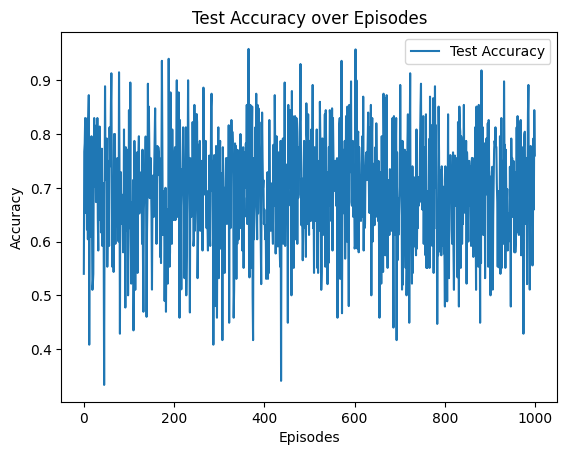

In [ ]:
import matplotlib.pyplot as plt

plt.plot(acc_list, label="Test Accuracy")
plt.xlabel("Episodes")
plt.ylabel("Accuracy")
plt.title("Test Accuracy over Episodes")
plt.legend()
plt.show()

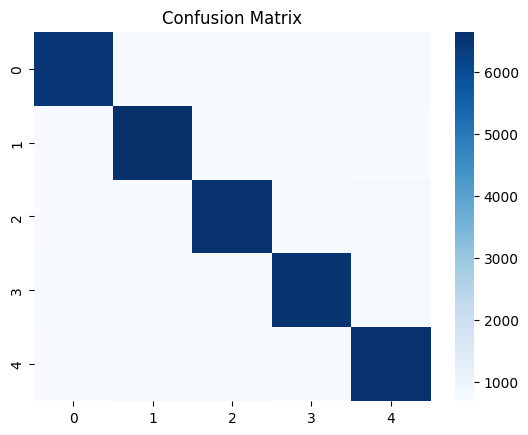

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()